# K-Means Clustering Analysis

## Objective
The purpose of this section is to apply K-Means clustering to group similar shipments based on operational and risk-related variables. This helps identify meaningful shipment segments such as efficient deliveries, high-risk shipments, or operationally costly movements.

The clustering analysis supports business decision-making by revealing hidden patterns in logistics performance, disruption exposure, and delivery behavior.

## Load the Cleaned Dataset
The cleaned dataset generated from the ETL stage is loaded for clustering analysis. This ensures that missing values, formatting issues, and inconsistencies have already been handled before model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/processed/cleaned_supply_chain_data.csv")
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Year,Month,Month_Name,Quarter
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39000,1,2025,10,October,4
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92000,1,2024,4,April,2
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54000,0,2024,1,January,1
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,49.85375,1,2024,10,October,4
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50000,1,2024,9,September,3


In [2]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 18)


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Year,Month,Month_Name,Quarter
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39000,1,2025,10,October,4
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92000,1,2024,4,April,2
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54000,0,2024,1,January,1
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,49.85375,1,2024,10,October,4
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50000,1,2024,9,September,3


## Feature Selection
The clustering model uses six numeric features that represent shipment scale, delivery performance, and operational risk. These variables were selected because they are directly related to supply chain efficiency and disruption exposure.

In [3]:
cluster_features = [
    'Distance_km',
    'Weight_MT',
    'Fuel_Price_Index',
    'Geopolitical_Risk_Score',
    'Carrier_Reliability_Score',
    'Lead_Time_Days'
]

X = df[cluster_features].copy()
X.head()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days
0,5930.83,197.42,2.43,5.0,0.865,41.39000
1,14285.36,237.24,2.30,7.5,0.592,40.92000
2,11113.91,427.42,1.78,5.6,0.673,11.54000
3,9180.55,170.66,3.20,0.8,0.832,49.85375
4,2762.27,434.96,2.77,1.9,0.741,0.50000


## Missing Value Validation
Before applying K-Means clustering, the selected variables were checked again for missing values to ensure model stability and avoid errors during scaling and clustering.

In [4]:
X.isnull().sum()

Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Carrier_Reliability_Score    0
Lead_Time_Days               0
dtype: int64

In [5]:
# Drop missing values if any exist
X = X.dropna()
df = df.loc[X.index].copy()

print("Dataset shape after missing value handling:", df.shape)

Dataset shape after missing value handling: (5000, 18)


## Feature Scaling
Standardization was applied using `StandardScaler` so that all variables contribute equally to the clustering process. This is necessary because K-Means relies on distance-based calculations.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (5000, 6)


## Elbow Method
The Elbow Method was used to identify a suitable number of clusters by measuring the within-cluster sum of squares (inertia) for different values of k. The best value is typically chosen near the point where the reduction in inertia starts to level off.

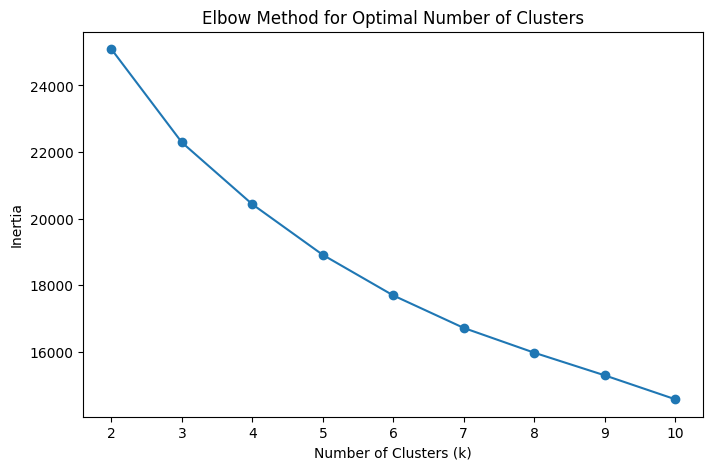

In [7]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.show()

### Silhouette Score Interpretation
Although the highest silhouette score may appear at a lower value such as k = 2, such a solution may be too broad for business interpretation. Based on both the Elbow Method and the need for meaningful shipment segmentation, k = 5 was selected as the final number of clusters.

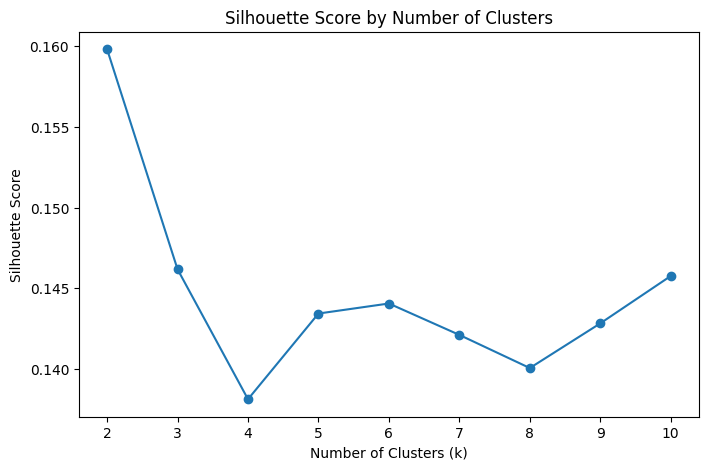

k = 2, silhouette score = 0.1598
k = 3, silhouette score = 0.1462
k = 4, silhouette score = 0.1381
k = 5, silhouette score = 0.1434
k = 6, silhouette score = 0.1441
k = 7, silhouette score = 0.1421
k = 8, silhouette score = 0.1401
k = 9, silhouette score = 0.1428
k = 10, silhouette score = 0.1458


In [8]:
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

for k, score in zip(range(2, 11), sil_scores):
    print(f"k = {k}, silhouette score = {score:.4f}")

## Final Choice of Cluster Count
Although the silhouette score was highest at a lower value of k, that solution would produce a very broad segmentation. Based on the Elbow Method, Silhouette Score, and the interpretability of the resulting cluster profiles, k = 5 was selected as the final number of clusters.

## Final K-Means Model
After reviewing the Elbow Method and Silhouette Score, the final K-Means model was trained using the selected number of clusters. Each shipment was then assigned to a cluster label.

In [9]:
final_k = 5

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df.loc[X.index, 'KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = df['KMeans_Cluster'].astype(int)
df[['KMeans_Cluster'] + cluster_features].head()

,KMeans_Cluster,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days
0,1,5930.83,197.42,2.43,5.0,0.865,41.39000
1,1,14285.36,237.24,2.30,7.5,0.592,40.92000
2,0,11113.91,427.42,1.78,5.6,0.673,11.54000
3,1,9180.55,170.66,3.20,0.8,0.832,49.85375
4,3,2762.27,434.96,2.77,1.9,0.741,0.50000


## Cluster Distribution
The number of records in each cluster was examined to understand how balanced the segmentation was and whether any cluster represented only a small minority of shipments.

In [10]:
df['KMeans_Cluster'].value_counts().sort_index()

KMeans_Cluster
0    1021
1     928
2    1004
3     988
4    1059
Name: count, dtype: int64

In [11]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features
).round(2)

cluster_centers.index.name = "KMeans_Cluster"
cluster_centers

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days
KMeans_Cluster,,,,,,
0,7136.11,305.53,1.98,7.26,0.77,8.38
1,10892.24,239.70,2.82,5.66,0.75,43.15
2,6671.64,202.84,3.78,7.28,0.77,7.94
3,7361.78,372.45,3.18,2.55,0.71,8.55
4,6750.77,117.56,2.55,2.73,0.76,7.51


## Cluster Profiling
To interpret the clusters, the mean values of the selected operational variables were calculated for each group. Disruption rate was also included to understand which shipment segments are more disruption-prone.

In [12]:
# Cluster summary table
cluster_summary = df.groupby('KMeans_Cluster').agg({
    'Distance_km': 'mean',
    'Weight_MT': 'mean',
    'Fuel_Price_Index': 'mean',
    'Geopolitical_Risk_Score': 'mean',
    'Carrier_Reliability_Score': 'mean',
    'Lead_Time_Days': 'mean',
    'Disruption_Occurred': 'mean'
}).round(2)

cluster_summary['Disruption_Occurred'] = (cluster_summary['Disruption_Occurred'] * 100).round(2)
cluster_summary = cluster_summary.rename(columns={'Disruption_Occurred': 'Disruption_Rate_%'})

cluster_summary

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Rate_%
KMeans_Cluster,,,,,,,
0,7132.81,305.35,1.98,7.26,0.77,8.38,64.0
1,10889.69,239.76,2.82,5.66,0.75,43.18,87.0
2,6675.23,203.09,3.78,7.29,0.77,7.95,65.0
3,7353.29,372.92,3.18,2.55,0.71,8.56,48.0
4,6765.93,117.71,2.55,2.73,0.76,7.51,45.0


## Cluster Interpretation

Based on the cluster summary table and supporting visualizations, the five clusters can be interpreted as follows:

- **Cluster 0 – High-Risk Medium-Heavy Shipments**  
  This cluster combines fairly high shipment weight with high geopolitical risk and a high disruption rate. It represents shipments that remain vulnerable despite relatively manageable lead times.

- **Cluster 1 – Critical Long-Distance Sea Shipments**  
  This is the most vulnerable cluster, characterized by the longest transport distance, the highest lead time, the highest disruption rate, dominant sea transport usage, and strong hurricane exposure.

- **Cluster 2 – Fuel-Exposed High-Risk Shipments**  
  This cluster is defined by the highest fuel price exposure and high geopolitical risk, together with a high disruption rate.

- **Cluster 3 – Heavy but Moderately Stable Shipments**  
  This cluster contains the heaviest shipments, but its disruption rate is lower than the most critical high-risk groups, suggesting that lower geopolitical risk improves stability.

- **Cluster 4 – Efficient Low-Risk Shipments**  
  This cluster represents the most efficient shipment group, with the lowest weight, shortest lead time, and lowest disruption rate.

## PCA Interpretation

The PCA visualization shows that Cluster 1 is clearly separated from the rest of the shipment groups, indicating a distinct high-risk operational profile. The remaining clusters show some overlap, suggesting that although they differ in important operational characteristics, their boundaries are less sharply separated. This is reasonable in real-world logistics data, where multiple shipment patterns may share similar features.

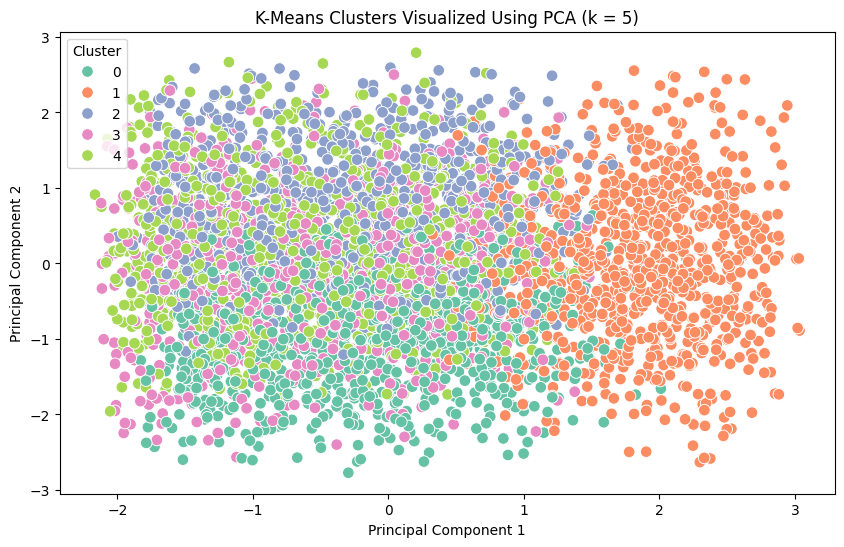

In [13]:
# PCA transformation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='KMeans_Cluster',
    palette='Set2',
    s=70
)
plt.title("K-Means Clusters Visualized Using PCA (k = 5)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

## Cluster Comparison by Feature
Boxplots were used to compare the distributions of the main operational variables across clusters. This helps reveal which variables most strongly differentiate the shipment groups.

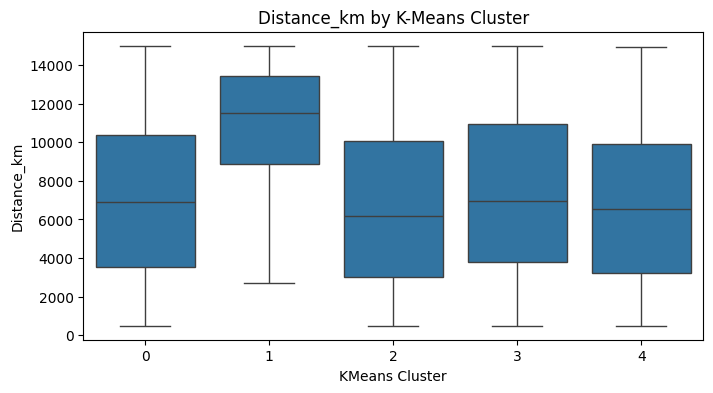

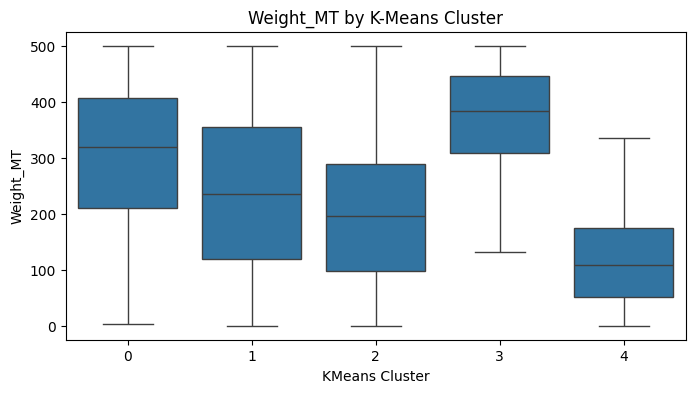

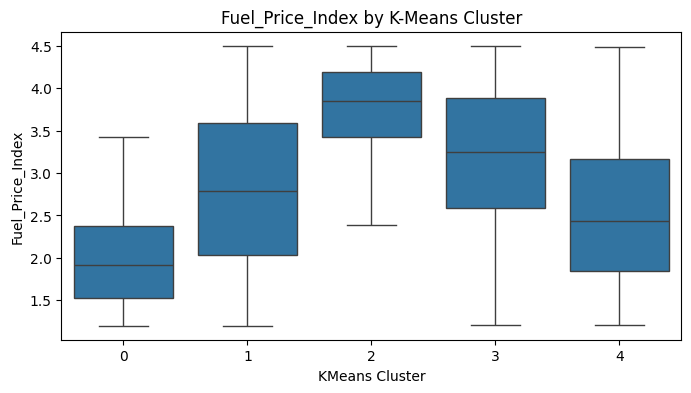

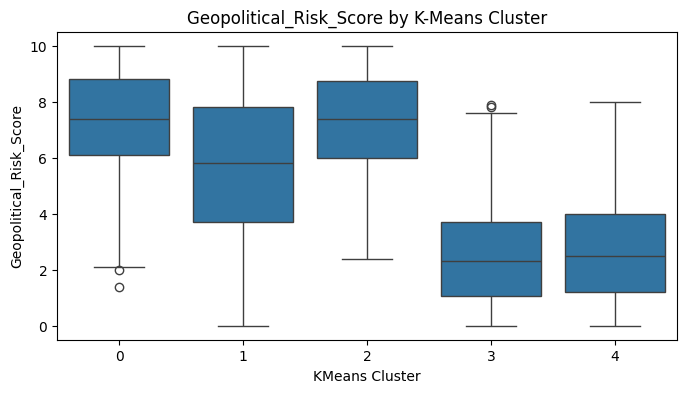

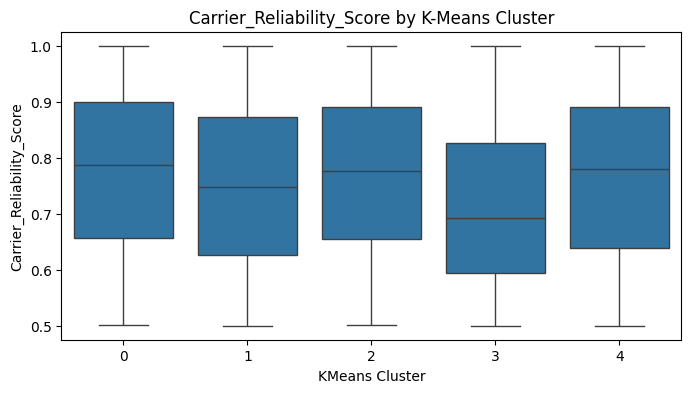

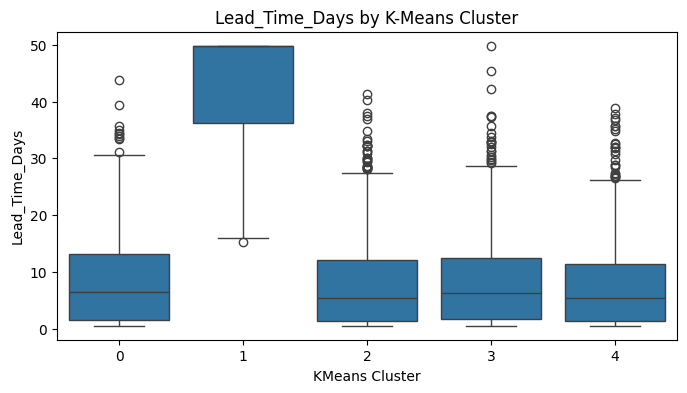

In [14]:
# Boxplots for each clustering feature
for col in cluster_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='KMeans_Cluster', y=col)
    plt.title(f"{col} by K-Means Cluster")
    plt.xlabel("KMeans Cluster")
    plt.ylabel(col)
    plt.show()

## Business-Level Cluster Interpretation
Cross-tabulations were created to examine how clusters differ by transport mode, product category, and weather condition. This helps connect the statistical clusters to practical supply chain operations.

In [15]:
# Transport Mode by Cluster
transport_cluster = pd.crosstab(
    df['KMeans_Cluster'],
    df['Transport_Mode'],
    normalize='index'
) * 100

transport_cluster.round(2)

Transport_Mode,Air,Rail,Road,Sea
KMeans_Cluster,,,,
0,34.28,24.00,24.49,17.24
1,0.00,26.19,20.26,53.56
2,33.76,22.61,25.10,18.53
3,30.26,24.09,25.00,20.65
4,31.35,21.91,26.16,20.59


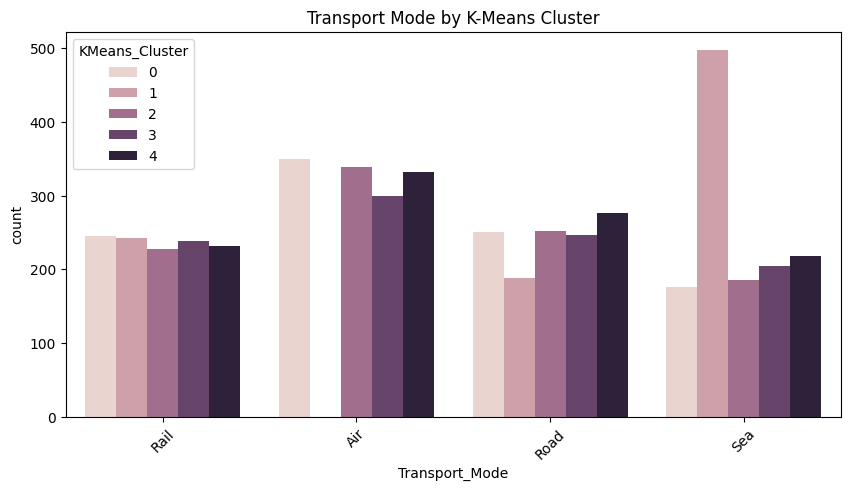

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Transport_Mode', hue='KMeans_Cluster')
plt.title("Transport Mode by K-Means Cluster")
plt.xticks(rotation=45)
plt.show()

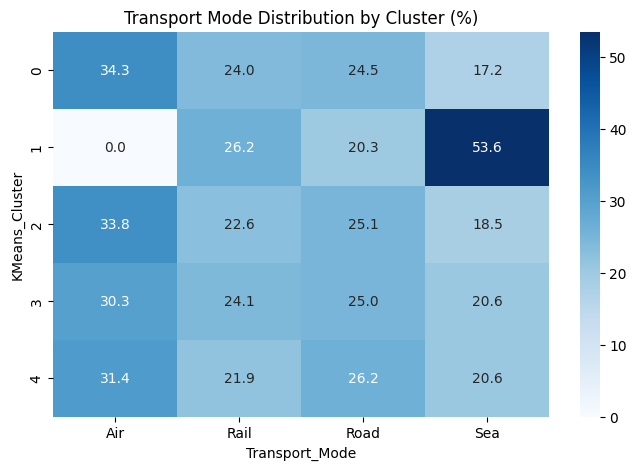

In [17]:
transport_cluster = pd.crosstab(df['KMeans_Cluster'], df['Transport_Mode'], normalize='index') * 100

plt.figure(figsize=(8,5))
sns.heatmap(transport_cluster, annot=True, fmt=".1f", cmap="Blues")
plt.title("Transport Mode Distribution by Cluster (%)")
plt.show()

In [18]:
# Weather Condition by Cluster
weather_cluster = pd.crosstab(
    df['KMeans_Cluster'],
    df['Weather_Condition'],
    normalize='index'
) * 100

weather_cluster.round(2)

Weather_Condition,Clear,Fog,Hurricane,Rain,Storm
KMeans_Cluster,,,,,
0,23.51,24.19,12.44,23.51,16.36
1,3.34,10.34,55.60,4.42,26.29
2,23.41,23.41,9.96,23.90,19.32
3,23.38,22.87,12.75,21.36,19.64
4,24.36,21.91,11.43,23.14,19.17


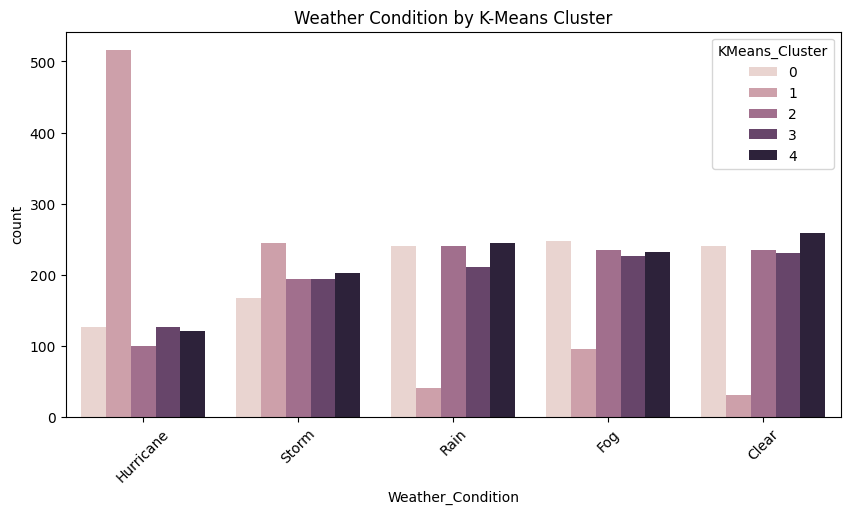

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Weather_Condition', hue='KMeans_Cluster')
plt.title("Weather Condition by K-Means Cluster")
plt.xticks(rotation=45)
plt.show()

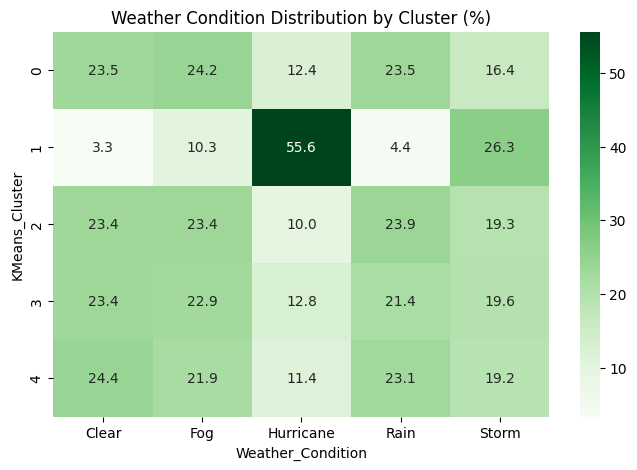

In [20]:
weather_cluster = pd.crosstab(df['KMeans_Cluster'], df['Weather_Condition'], normalize='index') * 100

plt.figure(figsize=(8,5))
sns.heatmap(weather_cluster, annot=True, fmt=".1f", cmap="Greens")
plt.title("Weather Condition Distribution by Cluster (%)")
plt.show()

In [21]:
# Product Category by Cluster
product_cluster = pd.crosstab(
    df['KMeans_Cluster'],
    df['Product_Category'],
    normalize='index'
) * 100

product_cluster.round(2)

Product_Category,Automotive,Electronics,Perishables,Pharmaceuticals,Textiles
KMeans_Cluster,,,,,
0,19.10,20.37,20.27,20.27,19.98
1,18.53,18.10,20.80,21.01,21.55
2,20.32,21.51,17.13,20.62,20.42
3,19.53,20.24,20.95,18.93,20.34
4,18.41,21.15,21.72,19.83,18.89


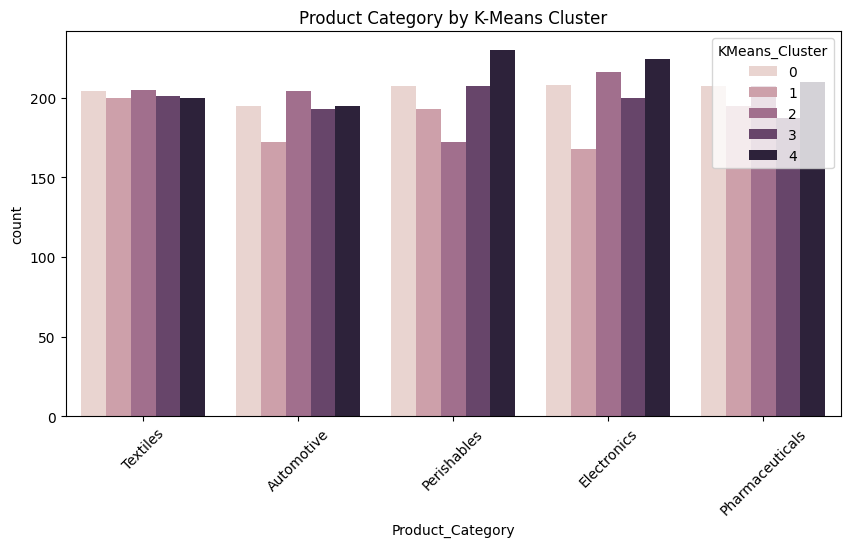

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Product_Category', hue='KMeans_Cluster')
plt.title("Product Category by K-Means Cluster")
plt.xticks(rotation=45)
plt.show()

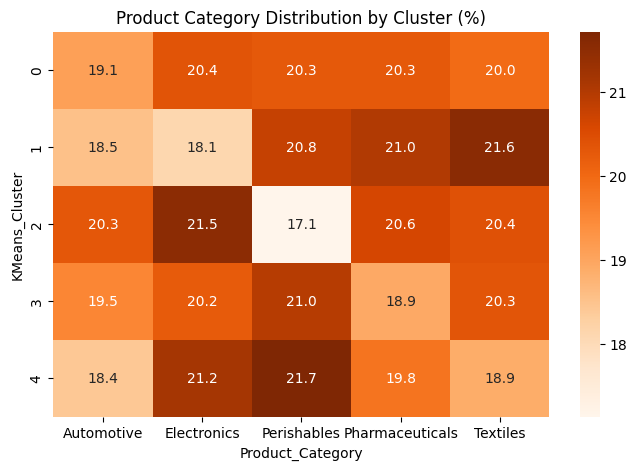

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(product_cluster, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Product Category Distribution by Cluster (%)")
plt.show()

## Key Business Insights

The K-Means clustering results reveal several important operational patterns:

1. **Cluster 1 is the highest-priority operational risk segment**  
   Cluster 1 is the most problematic shipment group because it combines the highest transport distance, the longest lead time, and the highest disruption rate. This cluster is also strongly associated with **Sea transport** and shows a high concentration of **Hurricane conditions**, indicating severe operational vulnerability.

2. **Extreme weather is a major disruption driver**  
   Weather distribution across clusters shows that Hurricane conditions are heavily concentrated in Cluster 1 compared to the other shipment groups. This suggests that extreme weather plays a major role in delays and disruptions for long-distance shipments.

3. **Geopolitical risk remains an important contributor to disruption**  
   Clusters 0 and 2 both show high geopolitical risk scores together with high disruption rates. This indicates that external regional instability can negatively affect shipment performance even when lead times are relatively lower than in Cluster 1.

4. **Product category is not a strong differentiator of cluster behavior**  
   Product categories are fairly evenly distributed across all clusters. This suggests that operational performance is influenced more by transport conditions, route characteristics, and environmental risk than by the type of product being shipped.

5. **Shipment weight alone does not determine disruption severity**  
   Although Cluster 3 contains the heaviest shipments, it does not have the highest disruption rate. This indicates that shipment weight is important for cost and handling considerations, but it is not the strongest driver of operational instability.

6. **Cluster 4 remains the most efficient shipment segment**  
   Cluster 4 shows the lowest shipment weight, the shortest lead time, the lowest disruption rate, and relatively low geopolitical risk. This makes it the most stable and efficient operational segment in the dataset.

Overall, the results suggest that **distance, transport mode, weather exposure, and geopolitical risk** are stronger drivers of disruption than product category alone.

## Recommendations

Based on the K-Means clustering results, the following recommendations are proposed:

- **Prioritize Cluster 1 for immediate operational intervention**  
  Since Cluster 1 represents the most disruption-prone shipment segment, it should be the primary focus for route redesign, shipment planning improvements, and resilience strategies.

- **Strengthen contingency planning for Sea transport routes**  
  Because Cluster 1 is strongly associated with sea transport and extreme weather exposure, alternative routing plans, buffer times, and emergency response measures should be developed for these shipments.

- **Introduce weather-aware logistics planning**  
  The strong concentration of hurricane conditions in Cluster 1 suggests that weather forecasting and seasonal risk planning should be integrated more directly into logistics operations.

- **Develop mitigation strategies for high geopolitical risk segments**  
  Clusters 0 and 2 should be monitored closely and supported with contingency actions such as alternative suppliers, route diversification, and flexible transport planning.

- **Use Cluster 4 as a performance benchmark**  
  Since Cluster 4 represents the most efficient shipment group, its operational practices can be studied and used as a benchmark for improving less efficient segments.

- **Focus cost optimization on heavy and fuel-sensitive shipments**  
  Clusters with high shipment weight and stronger fuel exposure should be reviewed for load optimization, route efficiency, and transport mode selection.

- **Do not rely heavily on product category for disruption management**  
  Since product category does not strongly differentiate the clusters, operational strategies should focus more on route conditions, transport mode, and environmental risk factors.

In [24]:
# Save outputs
cluster_summary.to_csv("../data/processed/kmeans_cluster_summary_k5.csv")
transport_cluster.round(2).to_csv("../data/processed/kmeans_transport_by_cluster_k5.csv")
product_cluster.round(2).to_csv("../data/processed/kmeans_product_by_cluster_k5.csv")
weather_cluster.round(2).to_csv("../data/processed/kmeans_weather_by_cluster_k5.csv")
df.to_csv("../data/processed/supply_chain_with_kmeans_k5.csv", index=False)

print("Files saved successfully:")
print("- kmeans_cluster_summary_k5.csv")
print("- kmeans_transport_by_cluster_k5.csv")
print("- kmeans_product_by_cluster_k5.csv")
print("- kmeans_weather_by_cluster_k5.csv")
print("- supply_chain_with_kmeans_k5.csv")

Files saved successfully:
- kmeans_cluster_summary_k5.csv
- kmeans_transport_by_cluster_k5.csv
- kmeans_product_by_cluster_k5.csv
- kmeans_weather_by_cluster_k5.csv
- supply_chain_with_kmeans_k5.csv


## Conclusion

The clustering results confirm that the most severe operational challenges are concentrated in Cluster 1, which is characterized by very long transport distance, high lead time, high disruption rate, dominant sea transport usage, and a strong concentration of hurricane conditions. This indicates that the most vulnerable shipment segment is shaped not only by distance, but also by transport mode and environmental exposure.

Clusters 0 and 2 also show elevated disruption levels, mainly associated with higher geopolitical risk. In contrast, Cluster 4 represents the most efficient and stable shipment segment, with lower weight, lower lead time, lower disruption, and lower geopolitical exposure.

The product category distributions are relatively balanced across clusters, suggesting that shipment performance is driven more by logistical and environmental conditions than by the type of product being transported. In addition, the PCA visualization shows that Cluster 1 is clearly separated from the rest of the shipment population, while the other clusters display more overlap. This suggests that the high-risk shipment segment is strongly distinct, whereas the remaining groups reflect more gradual differences in operational behavior.